In [ ]:
import sqlite3
import pandas as pd

In [ ]:
df = pd.read_csv("Online Retail.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
conn = sqlite3.connect("online_retail.db")

df.to_sql(
    "online_retail",
    conn,
    if_exists="replace",
    index=False
)

print("Data loaded into SQLite successfully")

Data loaded into SQLite successfully


In [ ]:
query = """
SELECT
    COUNT(*) AS total_records
FROM online_retail
"""
pd.read_sql(query, conn)

,total_records
0,86962


In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("online_retail.db")

In [ ]:
pd.read_sql("SELECT COUNT(*) AS total_records FROM online_retail", conn)

,total_records
0,86962


In [ ]:
conn.execute("""
DELETE FROM online_retail
WHERE InvoiceNo LIKE 'C%';
""")
conn.commit()

In [ ]:
conn.execute("""
DELETE FROM online_retail
WHERE Quantity <= 0 OR UnitPrice <= 0;
""")
conn.commit()

In [ ]:
conn.execute("""
DELETE FROM online_retail
WHERE CustomerID IS NULL;
""")
conn.commit()

In [ ]:
pd.read_sql("""
SELECT COUNT(*) AS records_after_cleaning
FROM online_retail
""", conn)

,records_after_cleaning
0,53919


In [ ]:
pd.read_sql("""
SELECT
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
FROM online_retail
""", conn)

,total_revenue
0,1291304.22


In [ ]:
pd.read_sql("""
SELECT
    Country,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
FROM online_retail
GROUP BY Country
ORDER BY revenue DESC
""", conn)

,Country,revenue
0,United Kingdom,1068151.69
1,Netherlands,36916.37
2,Germany,34774.62
3,EIRE,32533.50
4,France,30582.24
5,Spain,13598.16
6,Japan,13485.88
7,Australia,10310.51
8,Sweden,7830.12
9,Portugal,6495.68


In [ ]:
pd.read_sql("""
SELECT
    STRFTIME('%m', InvoiceDate) AS month,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
FROM online_retail
GROUP BY month
ORDER BY month
""", conn)

,month,revenue
0,None,1291304.22


In [ ]:
pd.read_sql("""
SELECT
    Description,
    SUM(Quantity) AS total_quantity,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
FROM online_retail
GROUP BY Description
ORDER BY total_quantity DESC
LIMIT 10
""", conn)

,Description,total_quantity,revenue
0,MEDIUM CERAMIC TOP STORAGE JAR,74215.0,77183.60
1,WHITE HANGING HEART T-LIGHT HOLDER,9898.0,26773.20
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,9460.0,2150.12
3,PACK OF 72 RETROSPOT CAKE CASES,7444.0,3451.00
4,JUMBO BAG RED RETROSPOT,5758.0,10071.30
5,MINI PAINT SET VINTAGE,5041.0,3053.45
6,HEART OF WICKER SMALL,4862.0,8239.34
7,PACK OF 12 LONDON TISSUES,4637.0,1262.65
8,ASSORTED COLOUR BIRD ORNAMENT,4617.0,7407.21
9,BROCADE RING PURSE,4401.0,744.21


In [ ]:
pd.read_sql("""
SELECT
    Description,
    SUM(Quantity) AS total_quantity
FROM online_retail
GROUP BY Description
ORDER BY total_quantity ASC
LIMIT 10
""", conn)

,Description,total_quantity
0,12 PINK HEN+CHICKS IN BASKET,1.0
1,5 STRAND GLASS NECKLACE AMBER,1.0
2,"ACRYLIC JEWEL SNOWFLAKE, PINK",1.0
3,AMBER FINE BEAD NECKLACE W TASSEL,1.0
4,AMETHYST DIAMANTE EXPANDABLE RING,1.0
5,ASSTD RASTA KEY-CHAINS,1.0
6,BATHROOM SCALES RUBBER DUCKS,1.0
7,BLACK CHRISTMAS TREE 120CM,1.0
8,BLACK FINE BEAD NECKLACE W TASSEL,1.0
9,BLACK+WHITE NECKLACE W TASSEL,1.0


In [ ]:
pd.read_sql("""
SELECT
    CustomerID,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
FROM online_retail
GROUP BY CustomerID
ORDER BY revenue DESC
LIMIT 10
""", conn)

,CustomerID,revenue
0,12346.0,77183.60
1,18102.0,38370.09
2,14646.0,36374.84
3,15749.0,22998.40
4,15061.0,22668.91
5,17450.0,20649.04
6,14156.0,17884.98
7,16029.0,16628.43
8,17511.0,15020.10
9,14911.0,13894.78


In [ ]:
monthly_df = pd.read_sql("""
SELECT
    STRFTIME('%Y-%m', InvoiceDate) AS month,
    SUM(Quantity * UnitPrice) AS revenue
FROM online_retail
WHERE InvoiceDate IS NOT NULL
GROUP BY month
ORDER BY month
""", conn)

monthly_df

,month,revenue
0,None,1291304.22


In [ ]:
monthly_df['month'] = monthly_df['month'].astype(str)

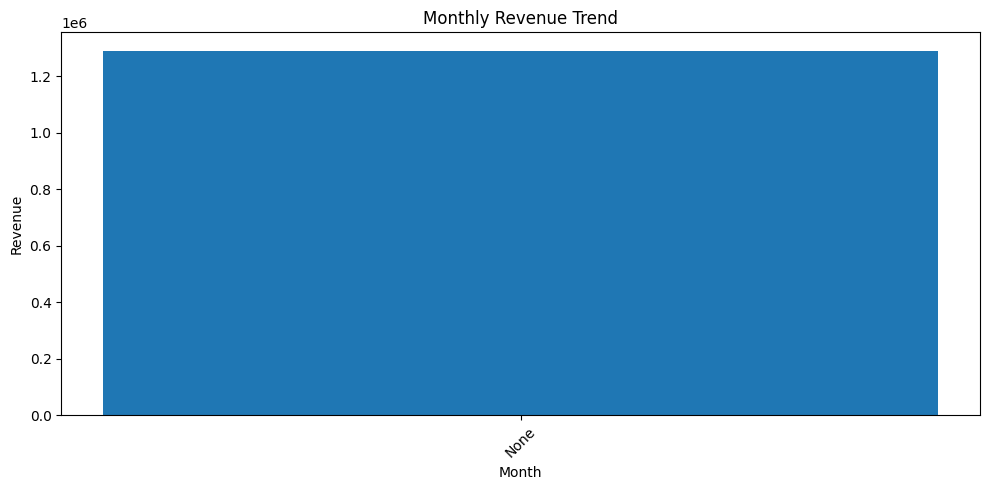

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(monthly_df['month'], monthly_df['revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [ ]:
monthly_df = monthly_df.sort_values('month')

In [ ]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

KeyError: 'Column not found: Revenue'

In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6.0,2.55,15.30
1,6.0,3.39,20.34
2,8.0,2.75,22.00
3,6.0,3.39,20.34
4,6.0,3.39,20.34


In [ ]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Revenue
Description,
DOTCOM POSTAGE,43022.93
REGENCY CAKESTAND 3 TIER,41206.51
WHITE HANGING HEART T-LIGHT HOLDER,27389.78
CHILLI LIGHTS,13820.79
VINTAGE UNION JACK MEMOBOARD,13730.90
JUMBO BAG RED RETROSPOT,10907.33
POSTAGE,10730.88
WOOD BLACK BOARD ANT WHITE FINISH,10293.91
HEART OF WICKER LARGE,9719.84


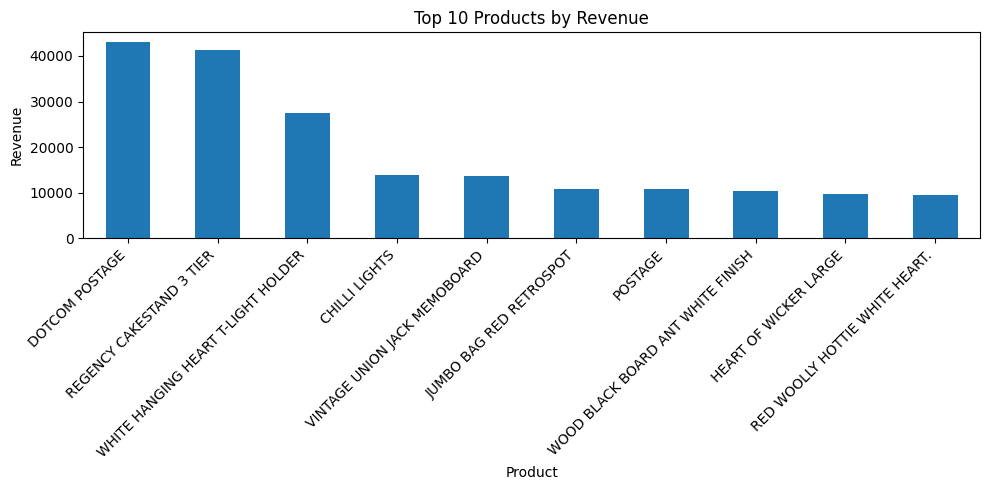

In [ ]:
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

,Revenue
Country,
United Kingdom,1265455.95
Netherlands,36836.57
Germany,33199.65
EIRE,32491.10
France,30304.24
Japan,13376.08
Spain,10690.61
Australia,10214.81
Sweden,6602.12


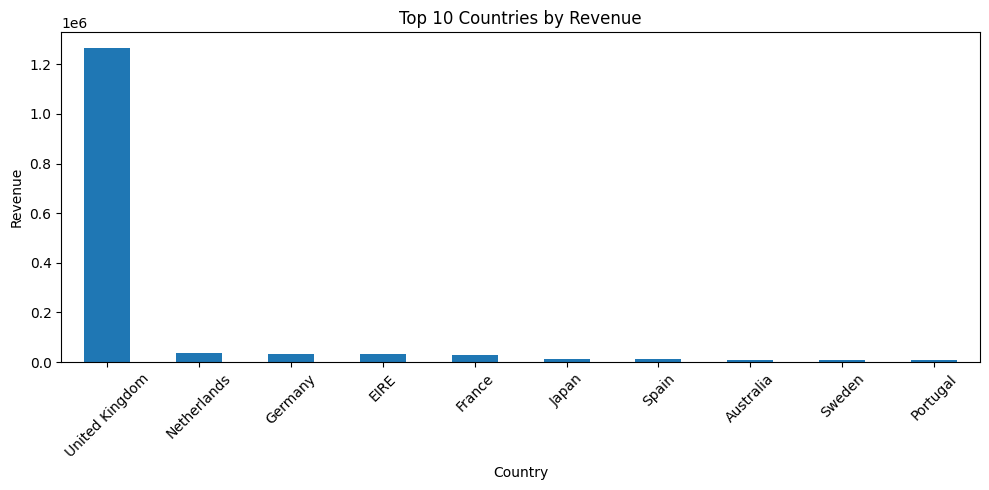

In [ ]:
plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,Revenue
CustomerID,
18102.0,38370.09
14646.0,36329.84
15749.0,22998.40
15061.0,22606.51
17450.0,20649.04
14156.0,17877.48
16029.0,16538.43
17511.0,14845.08
14911.0,12655.50


In [ ]:
import sqlite3

conn = sqlite3.connect("online_retail.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

86962

In [ ]:
import pandas as pd

query = """
SELECT
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
FROM sales
GROUP BY month
ORDER BY month;
"""

pd.read_sql(query, conn)

,month,revenue
0,None,1484612.01


In [ ]:
query = """
SELECT
    Description,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
FROM sales
GROUP BY Description
ORDER BY revenue DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Description,revenue
0,DOTCOM POSTAGE,43022.93
1,REGENCY CAKESTAND 3 TIER,41206.51
2,WHITE HANGING HEART T-LIGHT HOLDER,27389.78
3,CHILLI LIGHTS,13820.79
4,VINTAGE UNION JACK MEMOBOARD,13730.90
5,JUMBO BAG RED RETROSPOT,10907.33
6,POSTAGE,10730.88
7,WOOD BLACK BOARD ANT WHITE FINISH,10293.91
8,HEART OF WICKER LARGE,9719.84
9,RED WOOLLY HOTTIE WHITE HEART.,9495.80


KEY INSIGHTS


1.   UK is the highest revenue generating country
2.  A small set of products contributes most revenue
3. Seasonal spikes observed in certain months
4. High value customers can be targeted for loyalty programs

In [ ]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("Online Retail.csv", encoding="ISO-8859-1")

In [3]:
df = df.dropna()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

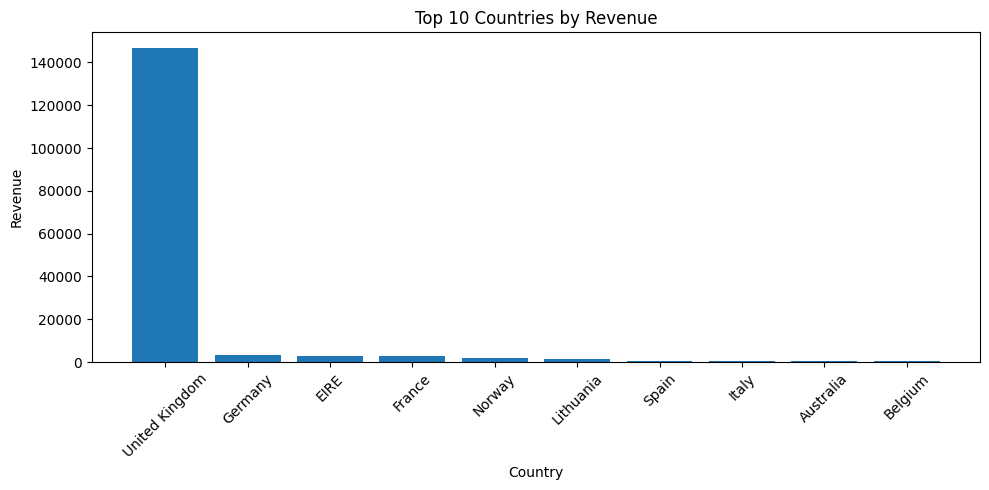

In [4]:
import matplotlib.pyplot as plt

country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(country_revenue.index, country_revenue.values)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("country_revenue_dashboard.png")
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


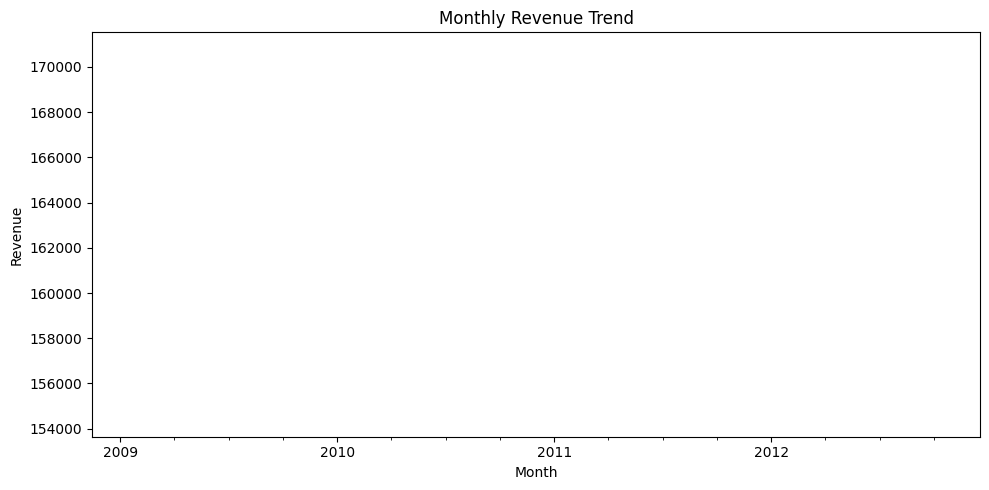

In [5]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()

plt.savefig("monthly_revenue_dashboard.png")
plt.show()

In [6]:
from google.colab import files

files.download("country_revenue_dashboard.png")
files.download("monthly_revenue_dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>